In [1]:
import pandas as pd
import pathlib
import numpy as np

# Carregamento e Tratamento de Dados

In [2]:
caminho_bases = pathlib.Path('Bases')
meses = {'jan': 1, 'fev': 2, 'mar': 3, 'abr': 4, 'mai': 5, 'jun': 6, 
         'jul': 7, 'ago': 8, 'set': 9, 'out': 10, 'nov': 11, 'dez': 12}

lista_dfs = []

for arquivo in caminho_bases.glob("*.csv"):
    nome_mes = arquivo.stem[:3].lower()
    # Extract year from the last 4 characters of the filename (before .csv)
    ano = int(arquivo.stem[-4:]) 
    
    df = pd.read_csv(arquivo)
    df['ano'] = ano
    df['mes'] = meses[nome_mes]
    
    lista_dfs.append(df)

base_airbnb = pd.concat(lista_dfs, ignore_index=True)

/tmp/ipykernel_4591/2246203303.py:12: DtypeWarning: Columns (61,62,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)
/tmp/ipykernel_4591/2246203303.py:12: DtypeWarning: Columns (87) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)
/tmp/ipykernel_4591/2246203303.py:12: DtypeWarning: Columns (62,87) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)
/tmp/ipykernel_4591/2246203303.py:12: DtypeWarning: Columns (61,62,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)
/tmp/ipykernel_4591/2246203303.py:12: DtypeWarning: Columns (61,62,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)
/tmp/ipykernel_4591/2246203303.py:12: DtypeWarning: Columns (61,62,94) have mixed types. Specify dtype option on import or set low_memory=False.

In [3]:
print(base_airbnb.columns.tolist())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary', 'space', 'description', 'experiences_offered', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 'house_rules', 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market', 'smart_location', 'country_code', 'country', 'latitude', 'longitude', 'is_location_exact', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'square_feet', 'price', 'weekly_price', 'monthly_price', '

In [4]:
base_airbnb = base_airbnb[['host_response_time',
 'host_response_rate',
 'host_is_superhost',
'host_listings_count',
'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'bed_type',
 'amenities',
'price',
'security_deposit',
 'cleaning_fee',
 'guests_included',
 'extra_people',
 'minimum_nights',
 'maximum_nights',
'number_of_reviews',
 'number_of_reviews_ltm',
'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
'instant_bookable',
 'is_business_travel_ready',                         
'cancellation_policy',
 'ano',
 'mes']]

In [5]:
base_airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 35 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   host_response_time           500367 non-null  object 
 1   host_response_rate           500364 non-null  object 
 2   host_is_superhost            901750 non-null  object 
 3   host_listings_count          901750 non-null  float64
 4   latitude                     902210 non-null  float64
 5   longitude                    902210 non-null  float64
 6   property_type                902210 non-null  object 
 7   room_type                    902210 non-null  object 
 8   accommodates                 902210 non-null  int64  
 9   bathrooms                    900486 non-null  float64
 10  bedrooms                     901360 non-null  float64
 11  beds                         899708 non-null  float64
 12  bed_type                     902210 non-null  object 
 13 

In [6]:
base_airbnb.isnull().sum()

host_response_time             401843
host_response_rate             401846
host_is_superhost                 460
host_listings_count               460
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bathrooms                        1724
bedrooms                          850
beds                             2502
bed_type                            0
amenities                           0
price                               0
security_deposit               421280
cleaning_fee                   313506
guests_included                     0
extra_people                        0
minimum_nights                      0
maximum_nights                      0
number_of_reviews                   0
number_of_reviews_ltm          301211
review_scores_rating           448016
review_scores_accuracy         448586
review_scores_cleanliness      448413
review_score

- Excluindo colunas com muitos dados faltantes

In [7]:
coluns = ['host_response_time','host_response_rate','security_deposit','cleaning_fee',
                  'number_of_reviews_ltm','review_scores_rating','review_scores_accuracy',
                  'review_scores_accuracy','review_scores_cleanliness','review_scores_checkin',
                 'review_scores_communication','review_scores_location','review_scores_value']

In [8]:
base_airbnb.drop(columns=coluns, inplace=True)

In [9]:
base_airbnb = base_airbnb.dropna()
print(base_airbnb.shape)

(897709, 23)


In [10]:
print(base_airbnb.dtypes)
print("-"*60)
base_airbnb.iloc[0]

host_is_superhost            object
host_listings_count         float64
latitude                    float64
longitude                   float64
property_type                object
room_type                    object
accommodates                  int64
bathrooms                   float64
bedrooms                    float64
beds                        float64
bed_type                     object
amenities                    object
price                        object
guests_included               int64
extra_people                 object
minimum_nights                int64
maximum_nights                int64
number_of_reviews             int64
instant_bookable             object
is_business_travel_ready     object
cancellation_policy          object
ano                           int64
mes                           int64
dtype: object
------------------------------------------------------------


host_is_superhost                                                           t
host_listings_count                                                       2.0
latitude                                                            -22.96592
longitude                                                           -43.17896
property_type                                                     Condominium
room_type                                                     Entire home/apt
accommodates                                                                5
bathrooms                                                                 1.0
bedrooms                                                                  2.0
beds                                                                      2.0
bed_type                                                             Real Bed
amenities                   {TV,"Cable TV",Internet,Wifi,"Air conditioning...
price                                                           

In [11]:

#price, extra people
base_airbnb['price'] = base_airbnb['price'].str.replace('$', '')
base_airbnb['price'] = base_airbnb['price'].str.replace(',', '')
base_airbnb['price'] = base_airbnb['price'].astype(np.float64, copy = False)

base_airbnb['extra_people'] = base_airbnb['extra_people'].str.replace('$', '')
base_airbnb['extra_people'] = base_airbnb['extra_people'].str.replace(',', '')
base_airbnb['extra_people'] = base_airbnb['extra_people'].astype(np.float64, copy = False)

# Analise Exploratória e Tratamento de Outliers

- Analisar cada feature para:
    1. Ver a correlação entre as features e decidir se manteremos todas as features que temos
    2. Excluir outliers (usaremos como regra, valores abaixo de Q1 - 1,5*Amplitude e valores acima de Q3 + 1,5*Amplitude). Amplitude = Q3 - Q1
    3. Confirmar se todas as features que temos fazem realmente sentido para o nosso modelo ou se alguma delas não vai nos ajudar e se devemos excluir

- Vamos começar pelas colunas preço e de extra_people que são valores numericos continuos

- Depois vamos analisar valores discretos

- Por fim analisar texto

obs: Nem todo outlier deve ser excluido sem critério

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

## Correlação entre as variáveis

<Axes: >

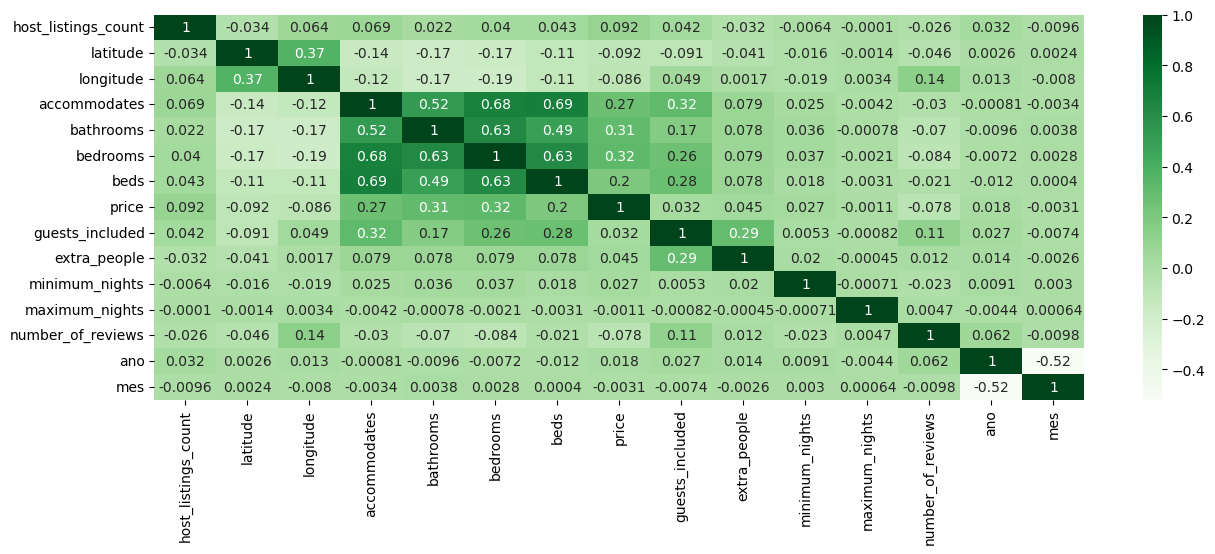

In [13]:
# Forma correta para evitar o erro de conversão
correlacao = base_airbnb.corr(numeric_only=True)


plt.figure(figsize=(15,5))
sns.heatmap(correlacao, annot =True, cmap="Greens")

In [14]:
def limites(coluna):
    q1 = coluna.quantile(0.25)
    q3 = coluna.quantile(0.75)
    amplitude = q3 - q1

    return q1 -1.5 * amplitude, q3 +1.5* amplitude

def excluir_outliers(df, nome_coluna):
    qtd_linhas = df.shape[0]
    lim_inf, lim_sup = limites(df[nome_coluna])
    df = df.loc[(df[nome_coluna] >= lim_inf) & (df[nome_coluna] <= lim_sup), :]
    linhas_removidas = qtd_linhas - df.shape[0]
    return df, linhas_removidas 

In [15]:
def diagrama_caixa(coluna):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(15,5)
    sns.boxplot(x=coluna, ax =ax1)
    ax2.set_xlim(limites(coluna))
    sns.boxplot(x=coluna, ax=ax2)

def histograma(coluna):
    plt.figure(figsize=(15, 5))
    # kde=True adiciona a linha da estimativa de densidade (antigo distplot)
    sns.histplot(coluna, kde=True, stat="density", color='royalblue')
    plt.title(f'Distribuição de {coluna.name}')
    plt.xlabel('Valor')
    plt.ylabel('Densidade')
    plt.show()

def barra(coluna):
    plt.figure(figsize=(15, 5))
    ax = sns.barplot(x=coluna.value_counts().index, y=coluna.value_counts())
    ax.set_xlim(limites(coluna))

### price

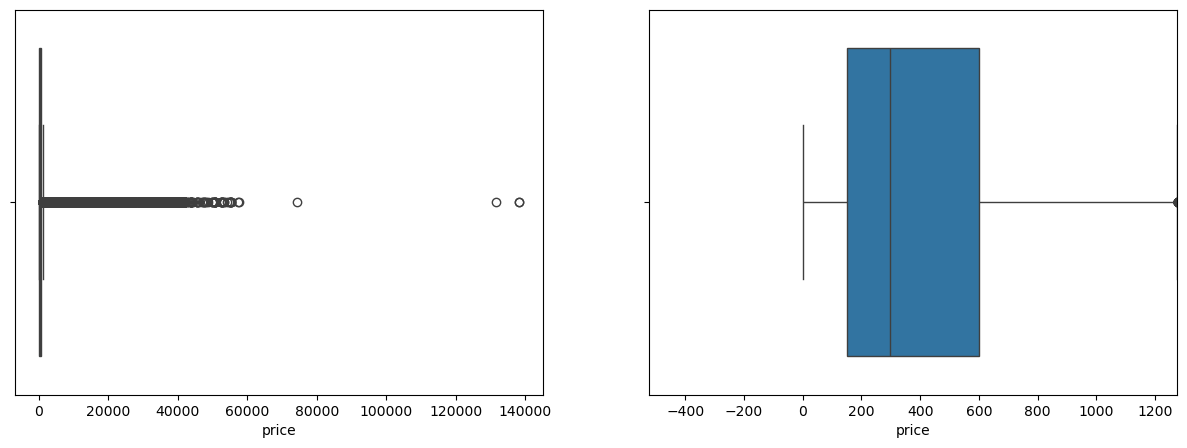

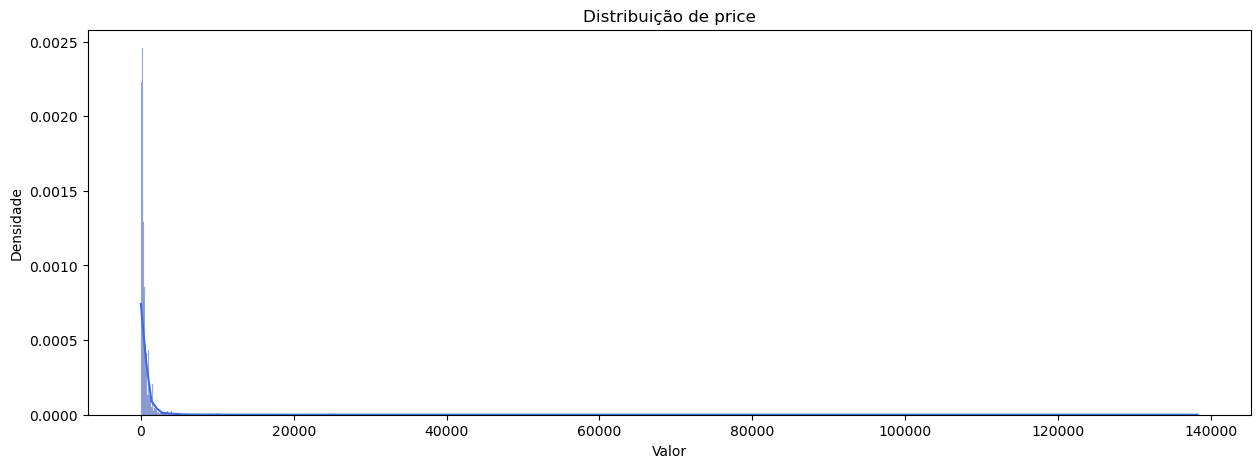

In [16]:
diagrama_caixa(base_airbnb['price'])
histograma(base_airbnb['price'])

In [17]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'price')


In [18]:
linhas_removidas

87282

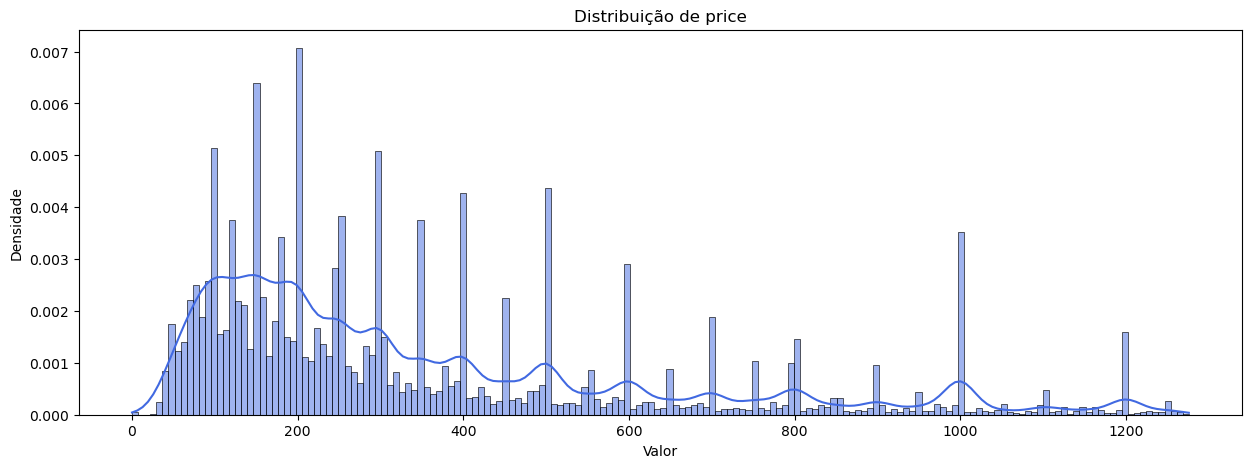

In [19]:
histograma(base_airbnb['price'])

### extra_people

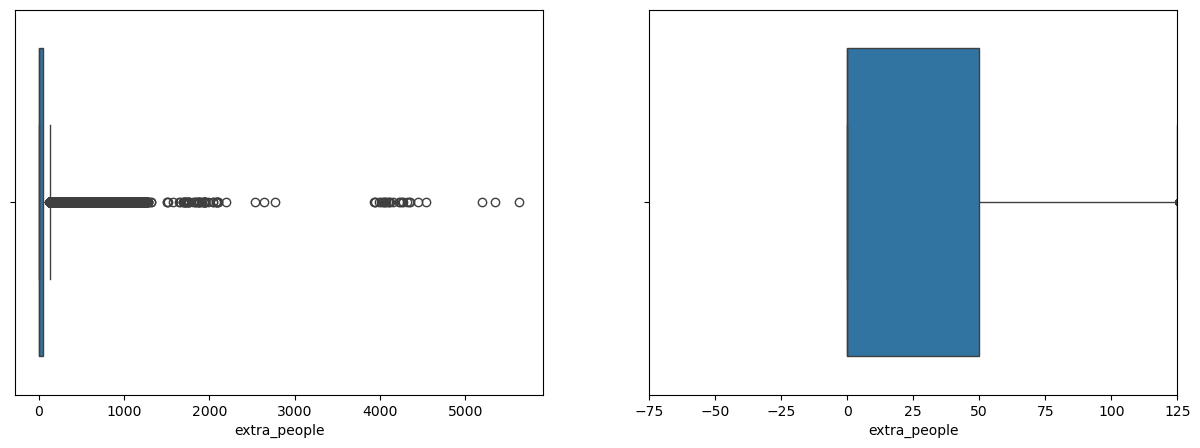

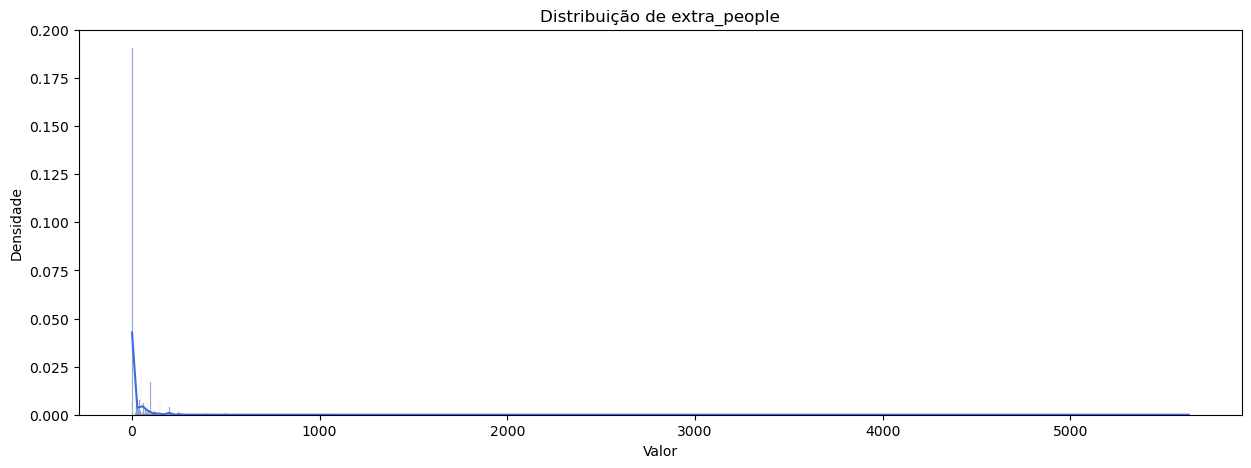

In [20]:
diagrama_caixa(base_airbnb['extra_people'])
histograma(base_airbnb['extra_people'])

In [21]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'extra_people')

In [22]:
linhas_removidas

59194

## Valores Discretos

### host_listings_count        
           


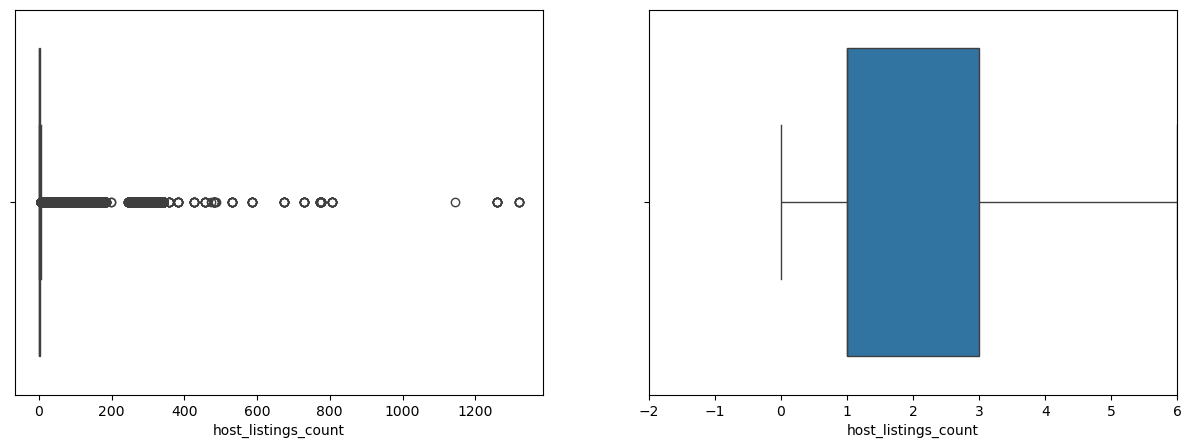

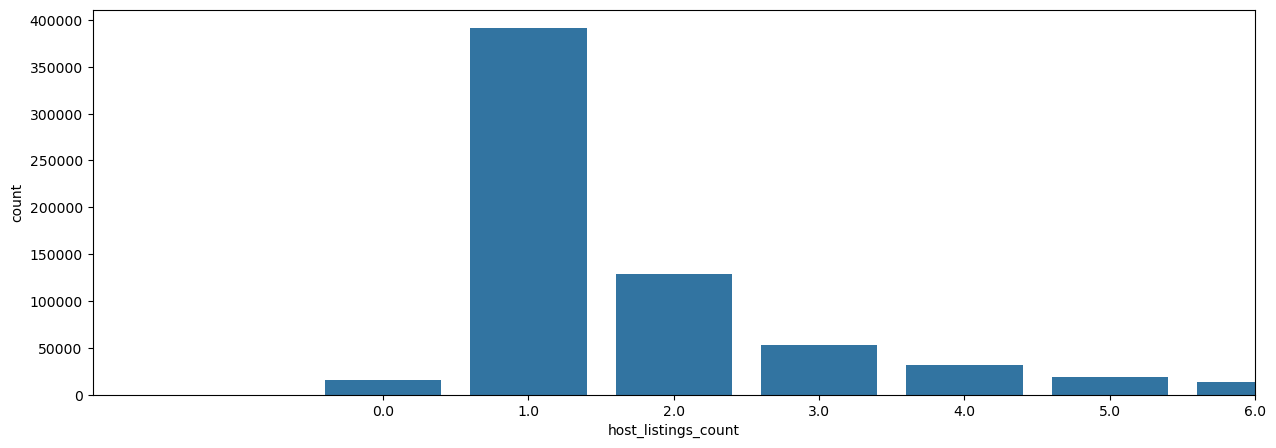

In [23]:
diagrama_caixa(base_airbnb['host_listings_count'])
barra(base_airbnb['host_listings_count'])

In [24]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'host_listings_count')

### accommodates                  


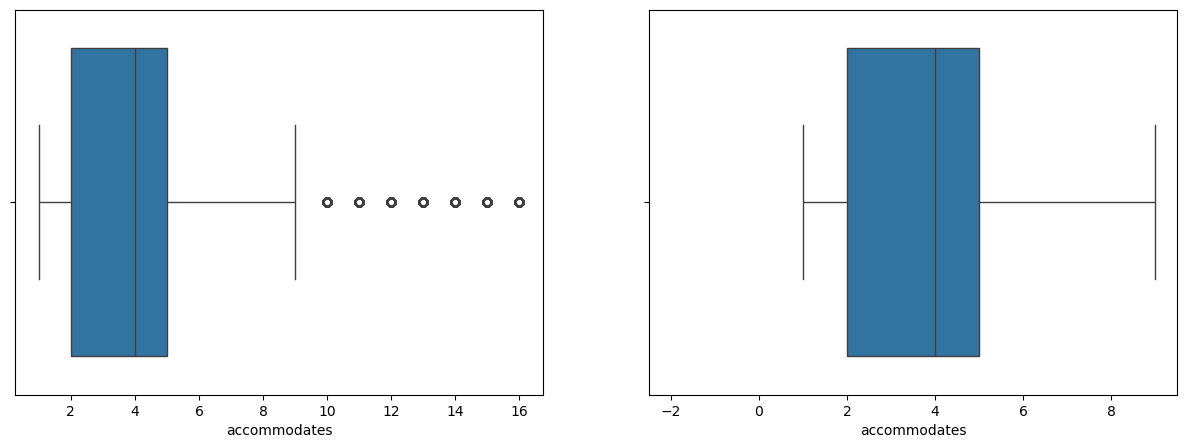

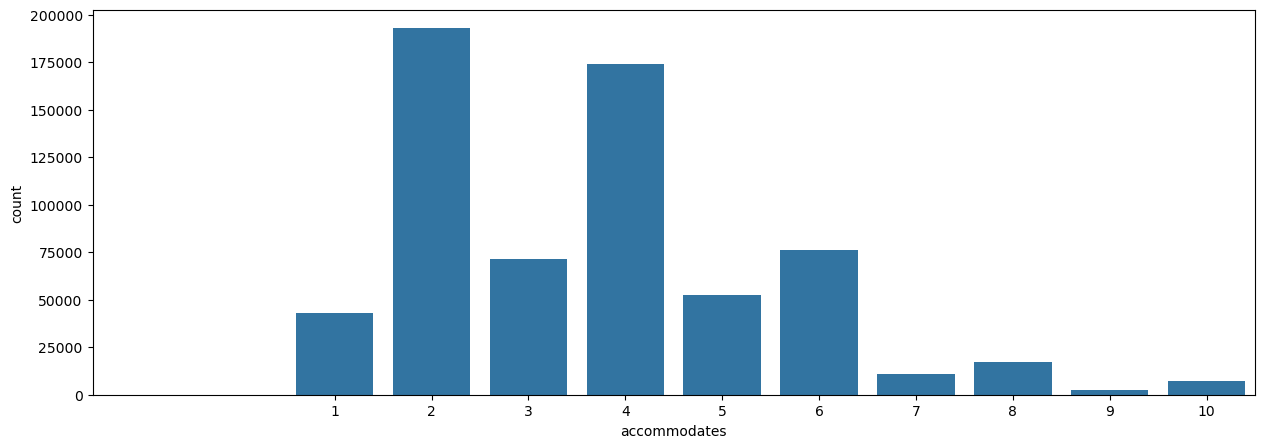

In [25]:
diagrama_caixa(base_airbnb['accommodates'])
barra(base_airbnb['accommodates'])

In [26]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'accommodates')

### bathrooms                   


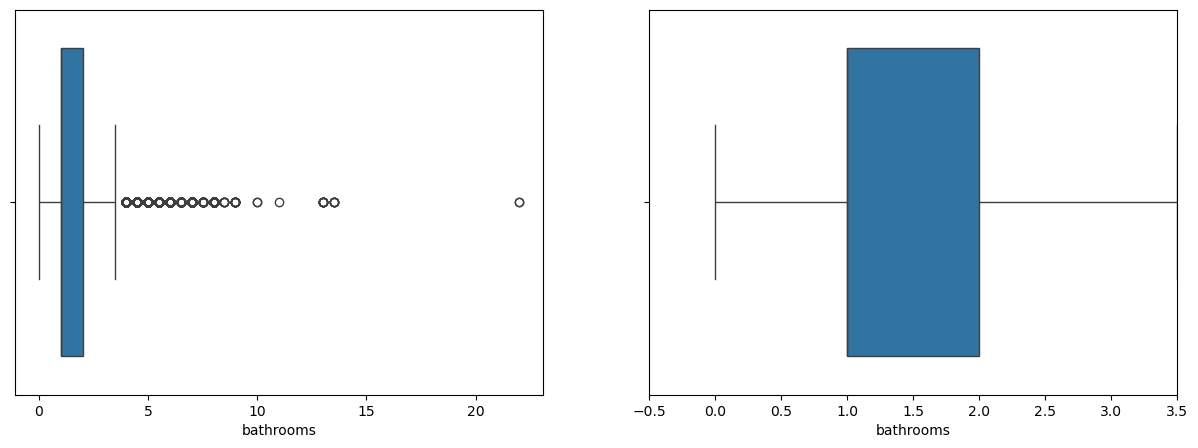

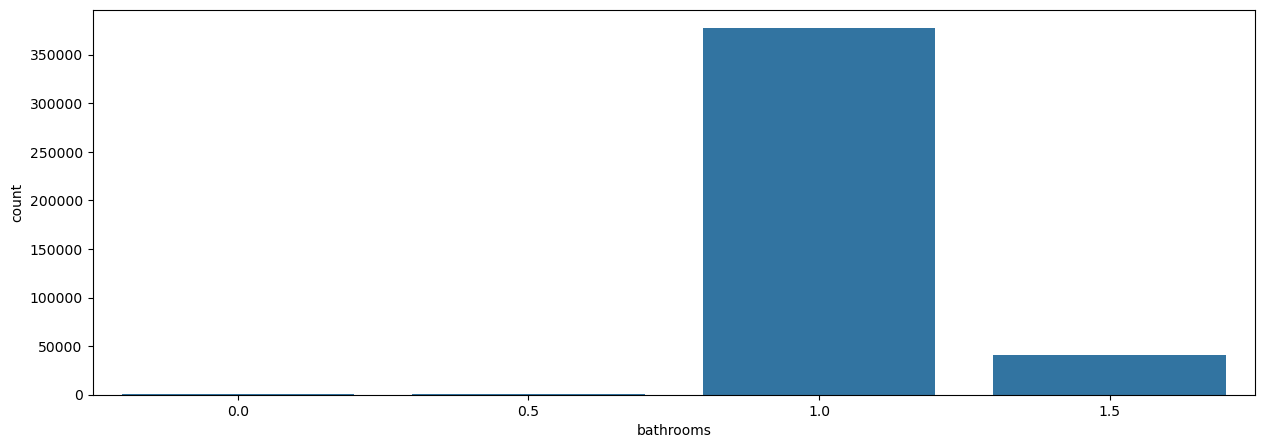

In [27]:
diagrama_caixa(base_airbnb['bathrooms'])
barra(base_airbnb['bathrooms'])

In [28]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'bathrooms')

### bedrooms                    
  

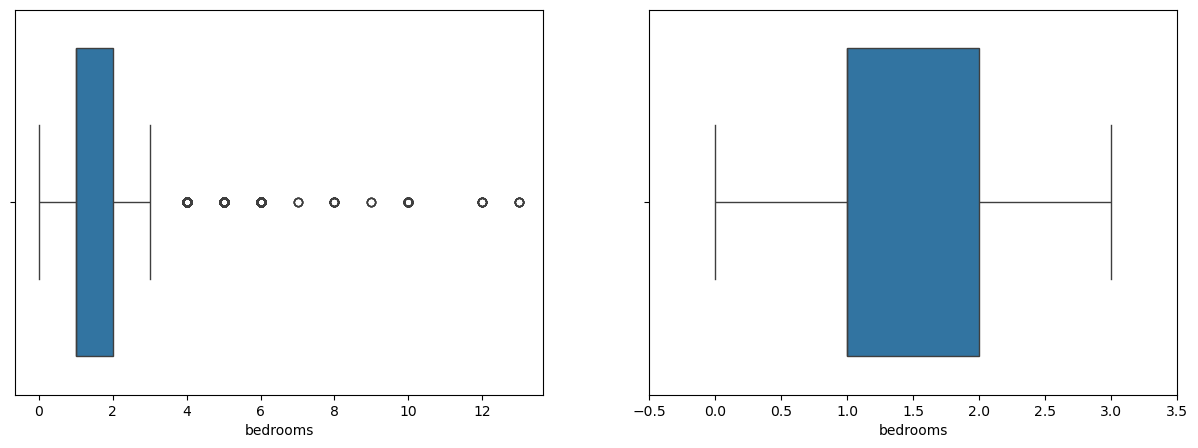

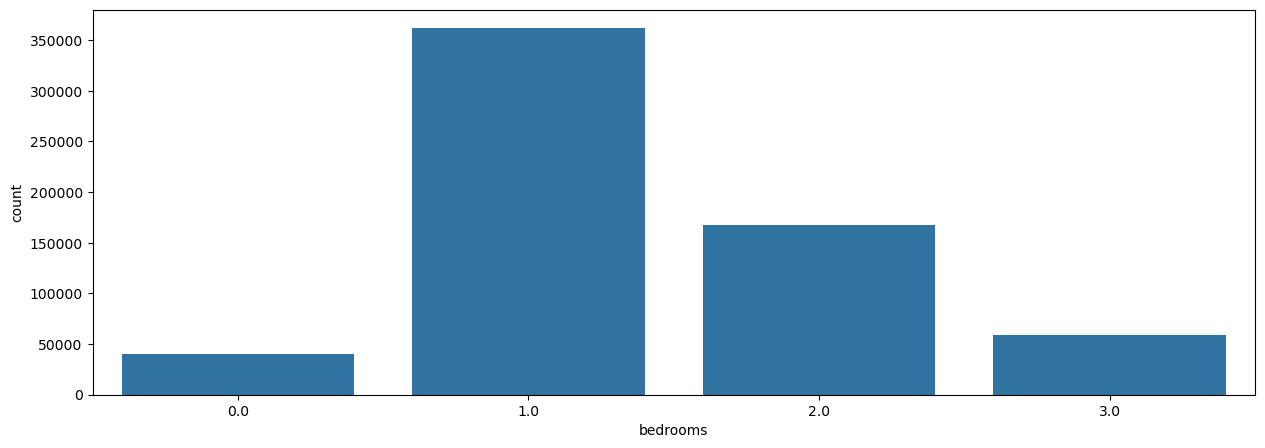

In [29]:
diagrama_caixa(base_airbnb['bedrooms'])
barra(base_airbnb['bedrooms'])

In [30]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'bedrooms')

### beds                        


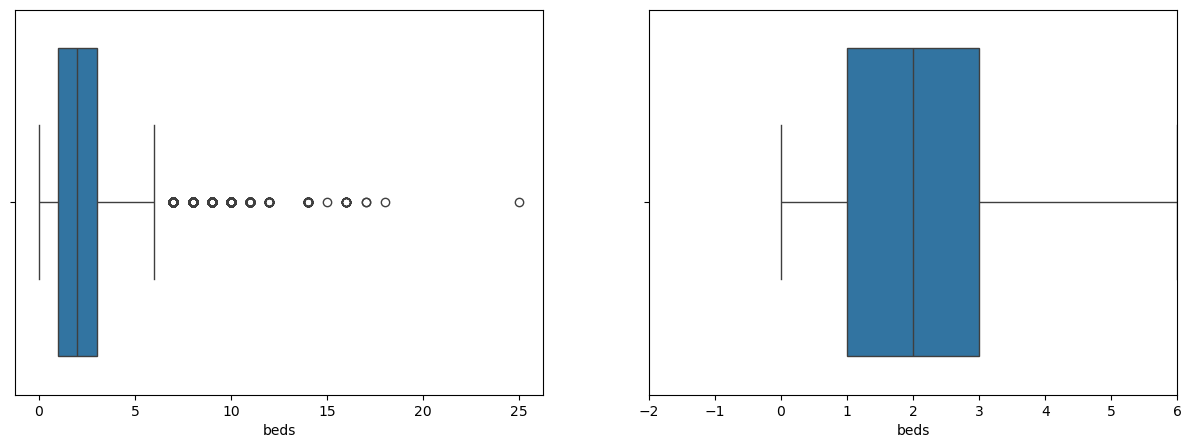

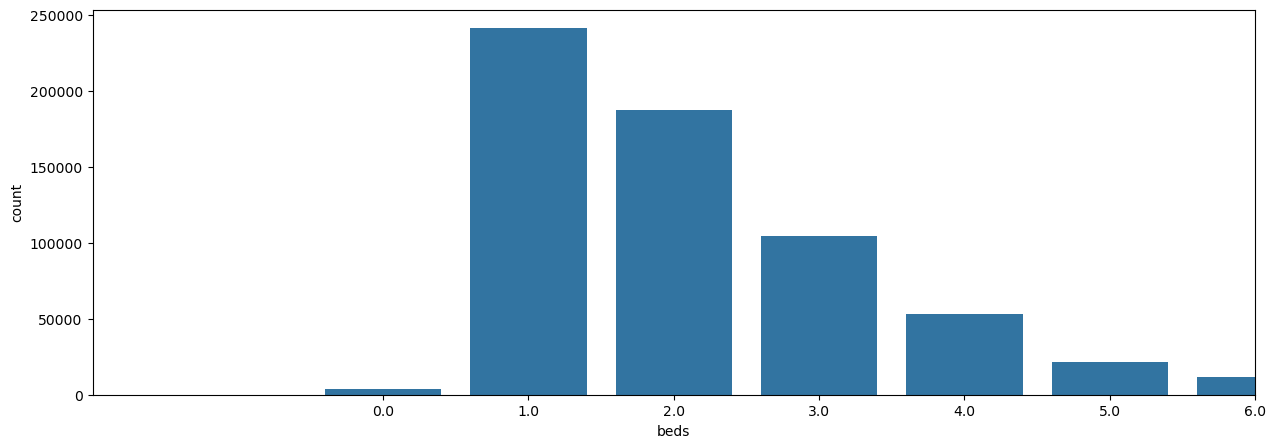

In [31]:
diagrama_caixa(base_airbnb['beds'])
barra(base_airbnb['beds'])

In [32]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'beds')

### guests_included               


/tmp/ipykernel_4591/4097013200.py:5: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax2.set_xlim(limites(coluna))
/tmp/ipykernel_4591/4097013200.py:20: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(limites(coluna))


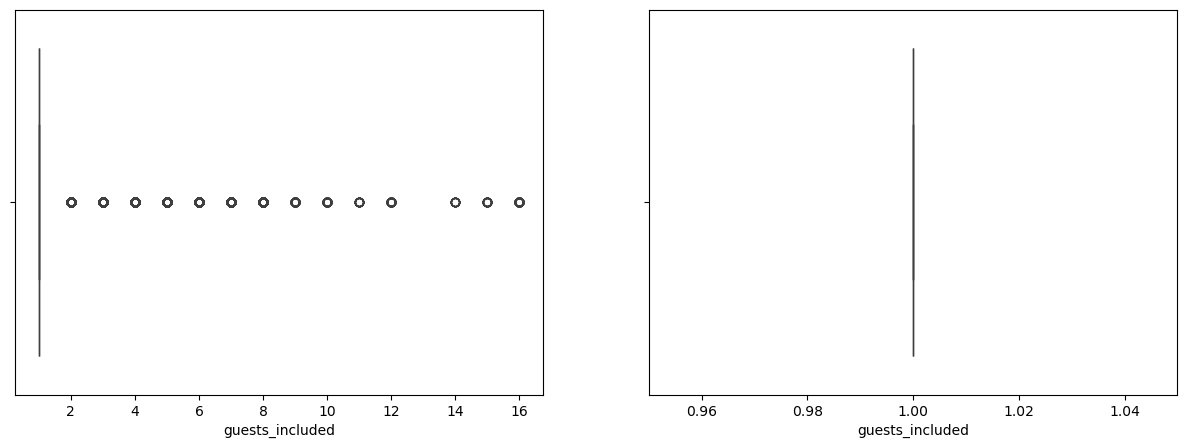

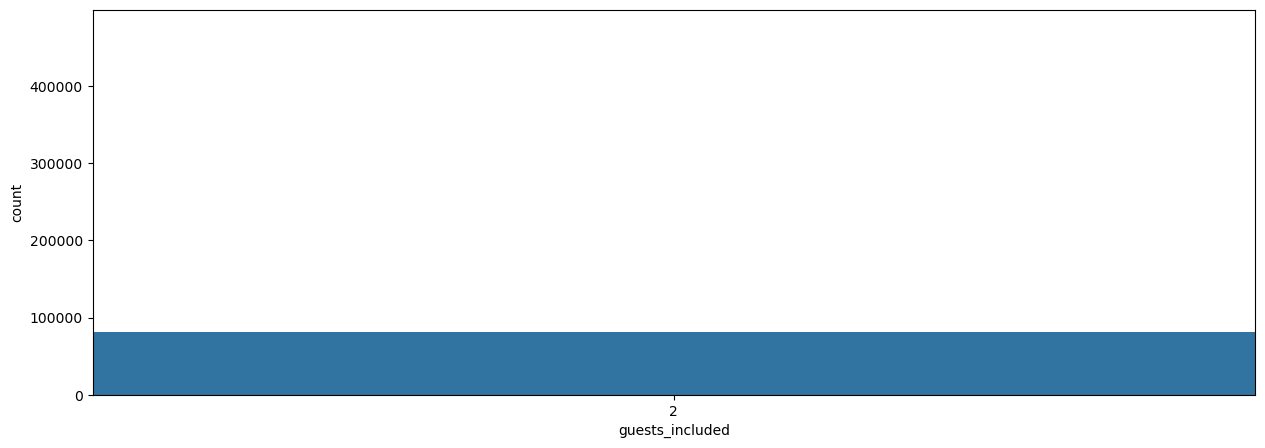

In [33]:
diagrama_caixa(base_airbnb['guests_included'])
barra(base_airbnb['guests_included'])

Não excluir essa feature e excluir ele da análise

In [34]:
base_airbnb = base_airbnb.drop('guests_included', axis = 1)

In [35]:
base_airbnb.shape

(622366, 22)

### minimum_nights                


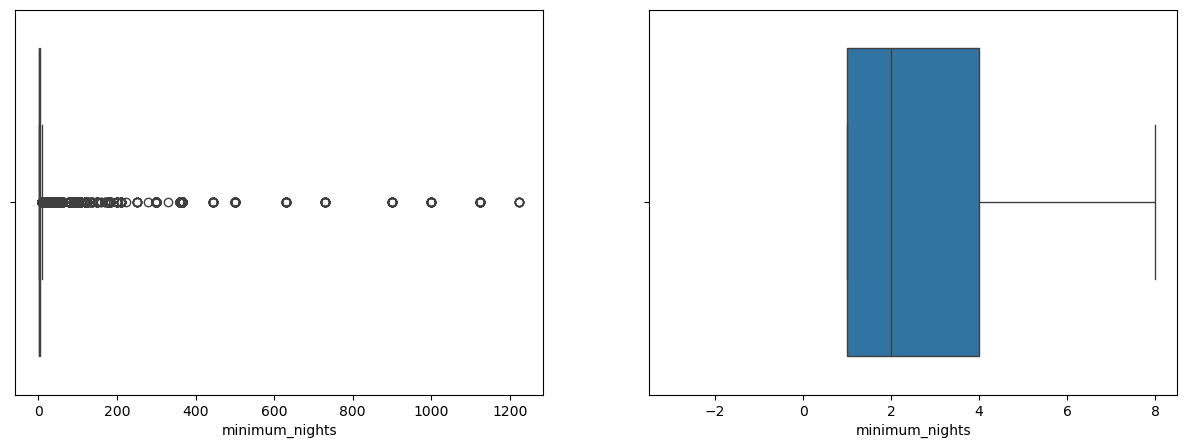

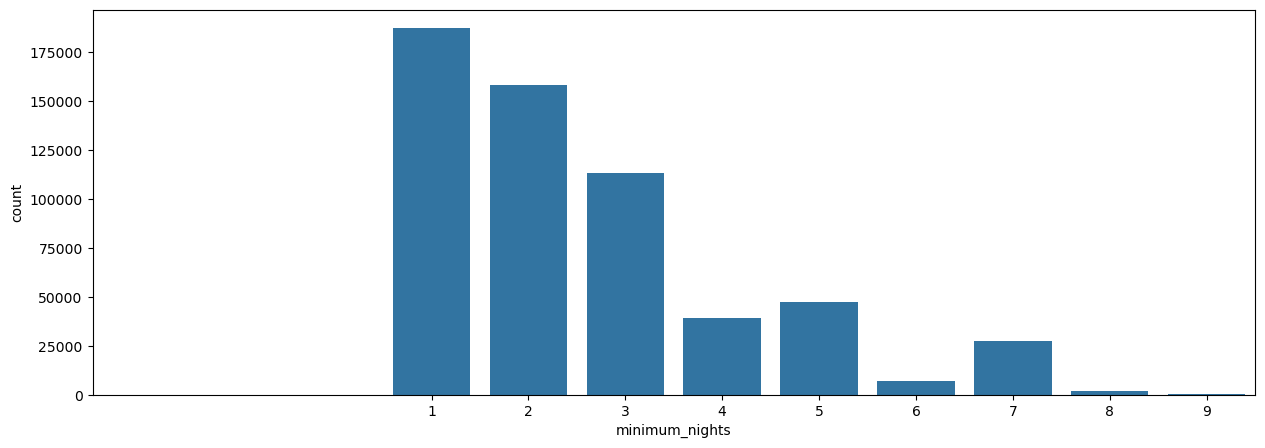

In [36]:
diagrama_caixa(base_airbnb['minimum_nights'])
barra(base_airbnb['minimum_nights'])

In [37]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'minimum_nights')
linhas_removidas

40383

### maximum_nights                


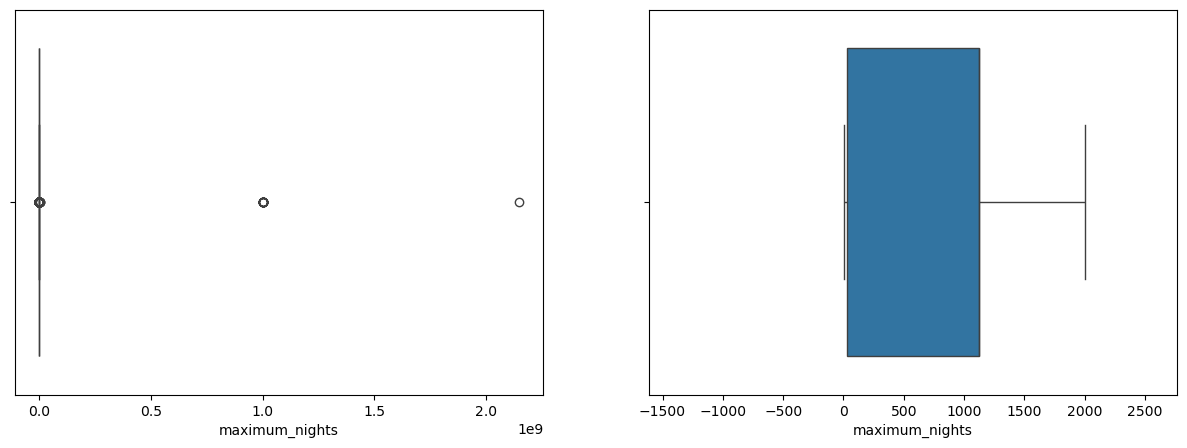

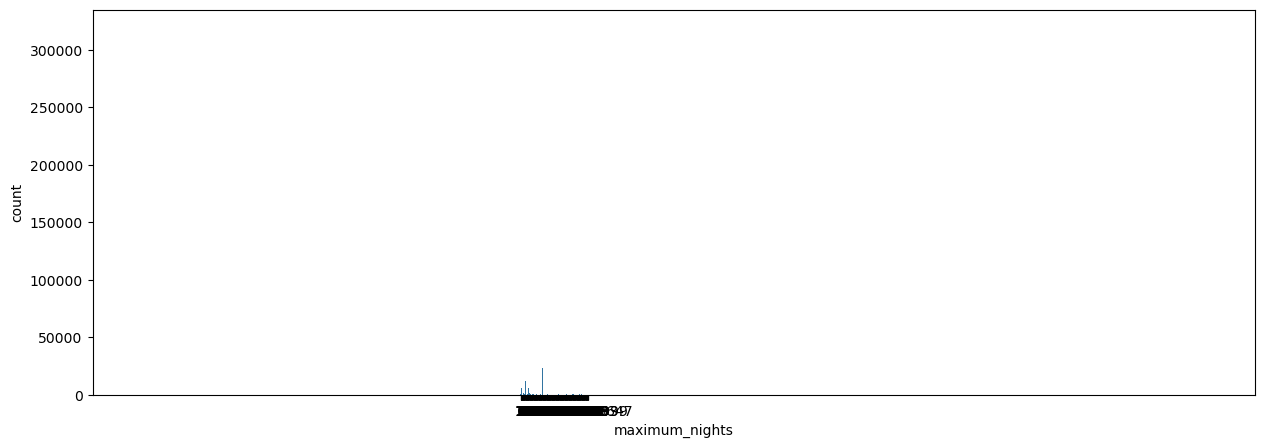

In [38]:
diagrama_caixa(base_airbnb['maximum_nights'])
barra(base_airbnb['maximum_nights'])

In [39]:
base_airbnb = base_airbnb.drop('maximum_nights', axis = 1)

### number_of_reviews

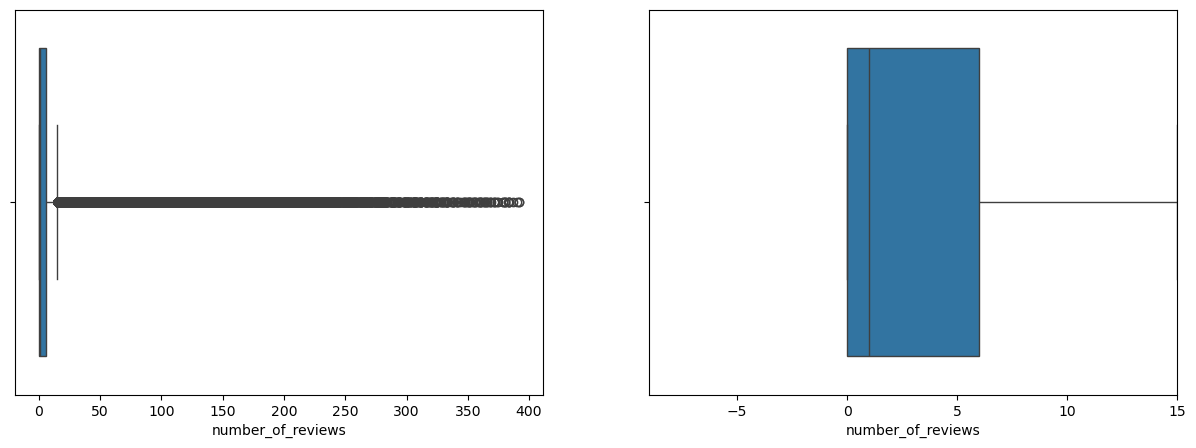

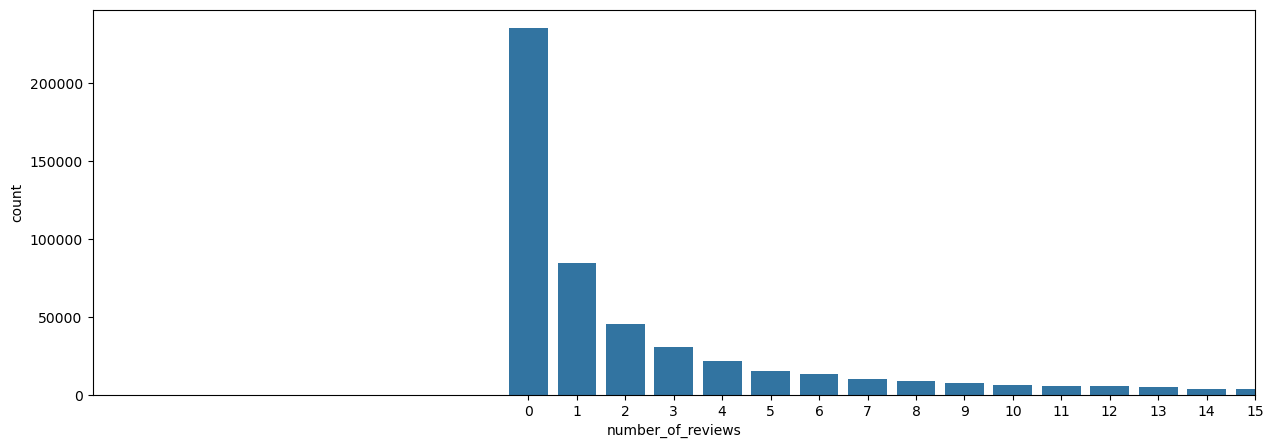

In [40]:
diagrama_caixa(base_airbnb['number_of_reviews'])
barra(base_airbnb['number_of_reviews'])

In [41]:
base_airbnb = base_airbnb.drop('number_of_reviews', axis = 1)

## Features Texto

### property_type

In [42]:
base_airbnb['property_type'].value_counts()
print(base_airbnb['property_type'].value_counts())

property_type
Apartment                 458354
House                      51387
Condominium                26456
Serviced apartment         12671
Loft                       12352
Guest suite                 3621
Bed and breakfast           3472
Hostel                      2665
Guesthouse                  2155
Other                       1957
Villa                       1294
Townhouse                    969
Aparthotel                   693
Chalet                       481
Earth house                  468
Tiny house                   457
Boutique hotel               447
Hotel                        376
Casa particular (Cuba)       298
Cottage                      230
Bungalow                     207
Dorm                         185
Cabin                        141
Nature lodge                 124
Castle                        80
Treehouse                     76
Island                        54
Boat                          53
Hut                           40
Campsite                     

In [43]:
tabela_tipos = base_airbnb['property_type'].value_counts()

colunas_agrupar = []

for tipo in tabela_tipos.index:
    if tabela_tipos[tipo] < 2000:
        colunas_agrupar.append(tipo)

for tipo in colunas_agrupar:
    base_airbnb.loc[base_airbnb['property_type'] == tipo, 'property_type'] = 'Others'

In [44]:
print(base_airbnb['property_type'].value_counts())

property_type
Apartment             458354
House                  51387
Condominium            26456
Serviced apartment     12671
Loft                   12352
Others                  8850
Guest suite             3621
Bed and breakfast       3472
Hostel                  2665
Guesthouse              2155
Name: count, dtype: int64


### room_type

In [45]:
base_airbnb['room_type'].value_counts()
print(base_airbnb['room_type'].value_counts())

room_type
Entire home/apt    372443
Private room       196859
Shared room         11714
Hotel room            967
Name: count, dtype: int64


### bed_type

In [46]:
base_airbnb['bed_type'].value_counts()
print(base_airbnb['bed_type'].value_counts())

bed_type
Real Bed         570643
Pull-out Sofa      8055
Futon              1634
Airbed             1155
Couch               496
Name: count, dtype: int64


In [47]:
tabela_tipos = base_airbnb['bed_type'].value_counts()

colunas_agrupar = []

for tipo in tabela_tipos.index:
    if tabela_tipos[tipo] < 10000:
        colunas_agrupar.append(tipo)

for tipo in colunas_agrupar:
    base_airbnb.loc[base_airbnb['bed_type'] == tipo, 'bed_type'] = 'Others'

In [48]:
print(base_airbnb['bed_type'].value_counts())

bed_type
Real Bed    570643
Others       11340
Name: count, dtype: int64


### cancellation_policy

In [49]:
base_airbnb['cancellation_policy'].value_counts()
print(base_airbnb['cancellation_policy'].value_counts())

cancellation_policy
flexible                       258096
strict_14_with_grace_period    200743
moderate                       113281
strict                           9696
super_strict_60                   135
super_strict_30                    32
Name: count, dtype: int64


In [50]:
tabela_tipos = base_airbnb['cancellation_policy'].value_counts()

colunas_agrupar = []

for tipo in tabela_tipos.index:
    if tabela_tipos[tipo] < 10000:
        colunas_agrupar.append(tipo)

for tipo in colunas_agrupar:
    base_airbnb.loc[base_airbnb['cancellation_policy'] == tipo, 'cancellation_policy'] = 'Strict'

In [51]:
print(base_airbnb['cancellation_policy'].value_counts())

cancellation_policy
flexible                       258096
strict_14_with_grace_period    200743
moderate                       113281
Strict                           9863
Name: count, dtype: int64


### amenities

In [52]:
print(base_airbnb['amenities'].iloc[1].split(','))
print(len(base_airbnb['amenities'].iloc[1].split(',')))
# Fixed: .str.split() instead of .str.plit()
base_airbnb['n_amenities'] = base_airbnb['amenities'].str.split(',').apply(len)

['{TV', '"Cable TV"', 'Internet', 'Wifi', '"Air conditioning"', 'Kitchen', 'Doorman', 'Elevator', '"Buzzer/wireless intercom"', '"Family/kid friendly"', 'Hangers', '"Hair dryer"', 'Iron', '"Laptop friendly workspace"}']
14


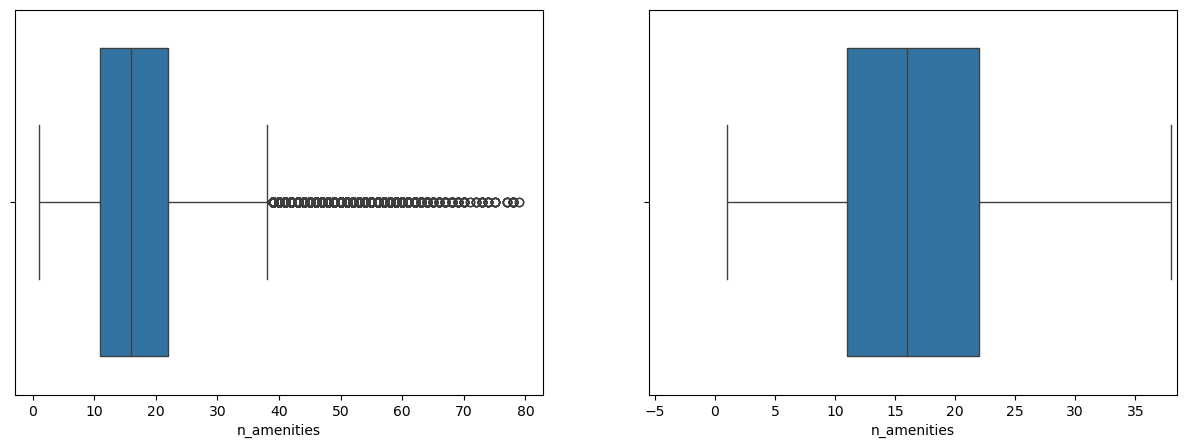

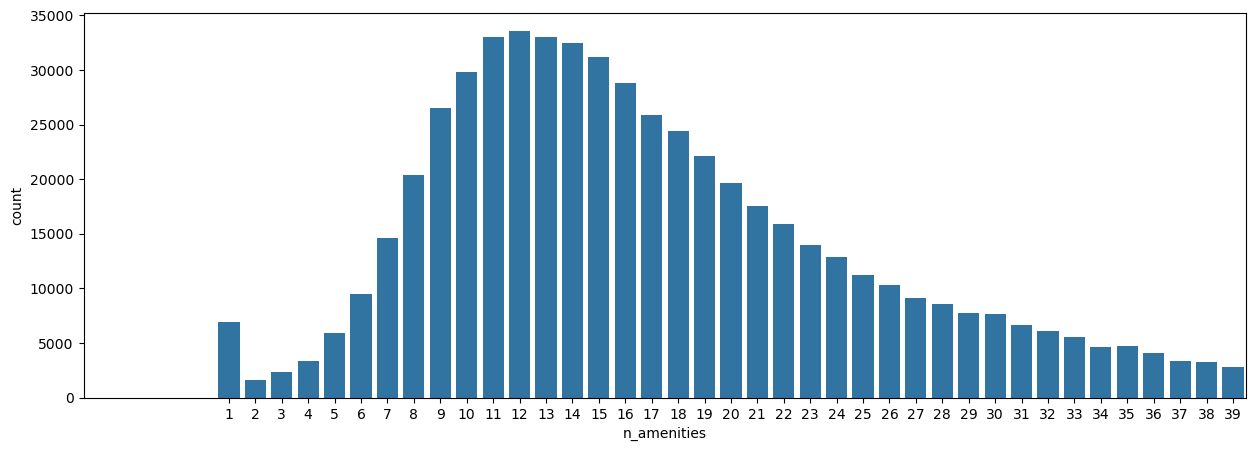

In [53]:
diagrama_caixa(base_airbnb['n_amenities'])
barra(base_airbnb['n_amenities'])

In [54]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, 'n_amenities')
base_airbnb = base_airbnb.drop('amenities', axis = 1)

In [55]:
import plotly.express as px

In [56]:
'''amostra = base_airbnb.sample(n=50000)
centro_mapa = {'lat': amostra.latitude.mean(), 'lon' : amostra.longitude.mean()}
# Updated to use px.density_map
fig = px.density_map(
    amostra, 
    lat='latitude', 
    lon='longitude', 
    z='price', 
    radius=1, 
    center=centro_mapa, 
    zoom=10, 
    map_style='open-street-map' # Replacement for stamen-terrain
)
fig.show()'''

"amostra = base_airbnb.sample(n=50000)\ncentro_mapa = {'lat': amostra.latitude.mean(), 'lon' : amostra.longitude.mean()}\n# Updated to use px.density_map\nfig = px.density_map(\n    amostra, \n    lat='latitude', \n    lon='longitude', \n    z='price', \n    radius=1, \n    center=centro_mapa, \n    zoom=10, \n    map_style='open-street-map' # Replacement for stamen-terrain\n)\nfig.show()"

## Encoding

Ajusta as features para facilitar o trabalho do modelo futuro 

- Features boleanas, vamos substituir True por 1 e False por 0
- Features Categóricas vamos usar o método de variáveis Dummies

In [57]:
print(base_airbnb.dtypes)

host_is_superhost            object
host_listings_count         float64
latitude                    float64
longitude                   float64
property_type                object
room_type                    object
accommodates                  int64
bathrooms                   float64
bedrooms                    float64
beds                        float64
bed_type                     object
price                       float64
extra_people                float64
minimum_nights                int64
instant_bookable             object
is_business_travel_ready     object
cancellation_policy          object
ano                           int64
mes                           int64
n_amenities                   int64
dtype: object


In [58]:
colunas_boolean = ['host_is_superhost', 'instant_bookable', 'is_business_travel_ready']
base_encod = base_airbnb.copy()
for coluna in colunas_boolean:
   base_encod.loc[base_encod[coluna] == 't', coluna] = 1
   base_encod.loc[base_encod[coluna] == 'f', coluna] = 0

In [59]:
colunas_dummie = ['property_type','room_type','bed_type','cancellation_policy']

In [60]:
base_encod = pd.get_dummies(data = base_encod, columns = colunas_dummie)

In [61]:
base_encod.head()

,host_is_superhost,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,extra_people,...,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room,bed_type_Others,bed_type_Real Bed,cancellation_policy_Strict,cancellation_policy_flexible,cancellation_policy_moderate,cancellation_policy_strict_14_with_grace_period
0,1,2.0,-22.96592,-43.17896,5,1.0,2.0,2.0,329.0,62.0,...,True,False,False,False,False,True,False,False,False,True
1,0,3.0,-22.97712,-43.19045,3,1.0,1.0,2.0,158.0,45.0,...,True,False,False,False,False,True,False,False,False,True
2,1,1.0,-22.98302,-43.21427,3,1.0,1.0,2.0,270.0,42.0,...,True,False,False,False,False,True,False,False,False,True
3,1,1.0,-22.98816,-43.19359,3,1.5,1.0,2.0,374.0,62.0,...,True,False,False,False,False,True,False,False,False,True
16,0,2.0,-22.92873,-43.17473,4,2.0,3.0,4.0,258.0,0.0,...,True,False,False,False,False,True,False,False,False,True


In [64]:
# Exemplo de redução manual para colunas de contagem e datas
cols_int = ['accommodates', 'minimum_nights', 'ano', 'mes', 'n_amenities']
base_encod[cols_int] = base_encod[cols_int].astype('int32')

In [65]:
base_encod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 557640 entries, 0 to 902209
Data columns (total 36 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   host_is_superhost                                557640 non-null  object 
 1   host_listings_count                              557640 non-null  float64
 2   latitude                                         557640 non-null  float64
 3   longitude                                        557640 non-null  float64
 4   accommodates                                     557640 non-null  int32  
 5   bathrooms                                        557640 non-null  float64
 6   bedrooms                                         557640 non-null  float64
 7   beds                                             557640 non-null  float64
 8   price                                            557640 non-null  float64
 9   extra_people        

In [66]:
# Salva como CSV (rápido e compatível)
base_encod.to_csv('basetreinamento.csv', index=False)